In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
### 1.Load digits dataset and view shapes of X and y to confirm dataset structure.
digits = load_digits()

X = digits.data   # Features (64 pixels)
y = digits.target # Labels (0–9)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (1797, 64)
Shape of y: (1797,)


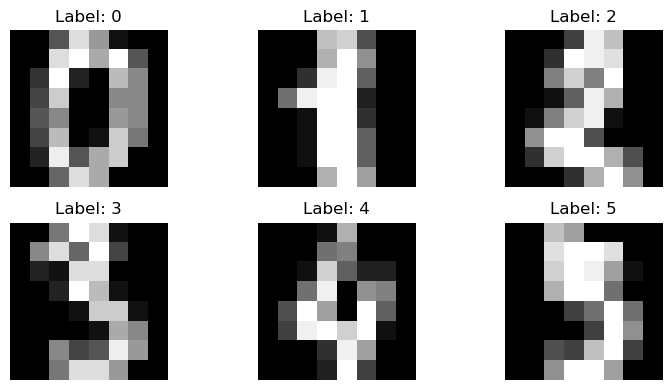

In [3]:
### 2.Visualize few digit images using matplotlib to confirm labels.
plt.figure(figsize=(8,4))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [4]:
### 3.Split dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
### 4.Apply feature scaling using StandardScaler since KNN uses distances.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
### 5.Train KNN model with K=3 and evaluate accuracy.
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (K=3):", accuracy)

Accuracy (K=3): 0.9666666666666667


In [7]:
### 6.Try multiple K values (3,5,7,9) and store results.
k_values = [3,5,7,9]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred_k = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_k)
    accuracies.append(acc)
    print(f"K={k}, Accuracy={acc}")

K=3, Accuracy=0.9666666666666667
K=5, Accuracy=0.9638888888888889
K=7, Accuracy=0.9666666666666667
K=9, Accuracy=0.9638888888888889


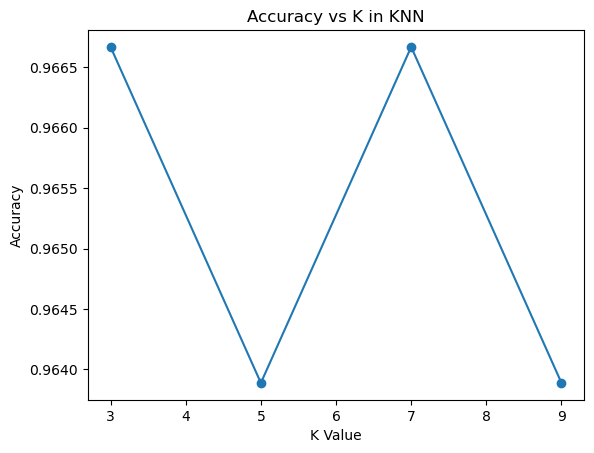

In [9]:
### 7.Plot accuracy vs K graph to pick best K.
plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K in KNN")
plt.show()


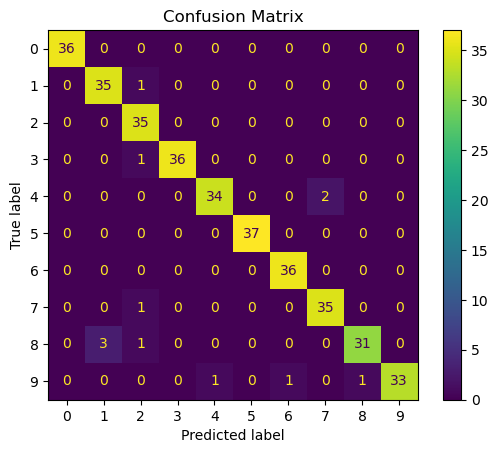

In [11]:
### 8.Generate confusion matrix to check misclassified digits.
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

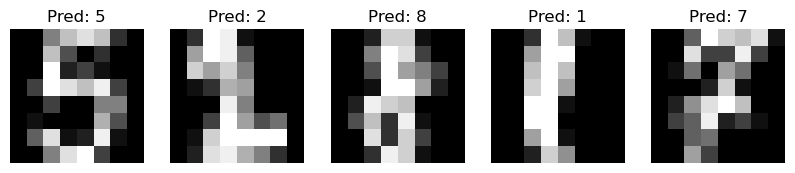

In [12]:
### 9.Display 5 test images with predicted labels to show final output.

plt.figure(figsize=(10,4))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(8,8), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')

plt.show()